# `analyze_integrability` — showcase notebook

This notebook illustrates every evidence **channel** of the redesigned
`IntegrabilityAnalysis.analyze_integrability` method through four physical
systems of increasing complexity.

| # | System | DOF | Character |
|---|--------|-----|-----------|
| 1 | Harmonic oscillator | 1 | Integrable |
| 2 | Double-well (anharmonic) | 1 | Integrable (nonlinear) |
| 3 | Isotropic 2-DOF oscillator | 2 | Integrable + algebraic hard gate |
| 4 | Hénon–Heiles | 2 | Mixed / chaotic |

### New API at a glance

The redesigned method replaces a single positional `spacings` argument
and a flat output dict with a structured four-channel architecture:

| Channel | Activated by | Output location | Hard gate? |
|---------|-------------|-----------------|------------|
| **Algebraic** | `H=`, `vars_phase=`, `second_integrals=` | `channels['algebraic']` | Yes → `'Integrable'` |
| **Spectral** | `levels=` (auto-unfolded) or `spacings=` | `channels['spectral']` | No |
| **Frequency** | `traj=`, `ndof=` | `channels['frequency']` | No |
| **Lyapunov** | `traj=` + `vars_phase=` | `channels['lyapunov']` | Yes → `'Chaotic'` |

Top-level keys always present: `verdict`, `verdict_source`, `soft_score`,
`channels`, `warnings`, `summary`.

Each section below:
- defines the Hamiltonian symbolically,
- integrates trajectories and builds a synthetic spectrum,
- calls `analyze_integrability` with the appropriate channels,
- and produces a multi-panel visualisation.

## 0 · Imports and helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from fractions import Fraction
from sympy import symbols, simplify

from symplectic import (
    hamiltonian_flow,
    poisson_bracket,
    action_integral,
    phase_portrait,
    poincare_section,
    IntegrabilityAnalysis,
)

# ── plotting defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'lines.linewidth': 1.4,
})

PALETTE = {
    'integrable': '#1d9e75',
    'chaotic':    '#d85a30',
    'mixed':      '#ba7517',
    'poisson':    '#378add',
    'wigner':     '#d4537e',
    'neutral':    '#888780',
}

# ── spectrum helpers ──────────────────────────────────────────────────────────
# The new API takes raw energy *levels* (not pre-computed spacings).
# It unfolds them internally via polynomial fitting to the staircase N(E).

def synthetic_levels(kind='poisson', n=600, seed=0):
    """Cumulative sum of inter-level gaps → a synthetic energy spectrum.

    'poisson' gaps  → integrable (Berry-Tabor) statistics after unfolding.
    'wigner'  gaps  → chaotic   (BGS/GOE)      statistics after unfolding.
    'mixed'   gaps  → half-and-half mixture.
    """
    rng = np.random.default_rng(seed)
    if kind == 'poisson':
        gaps = rng.exponential(1.0, n)
    elif kind == 'wigner':
        gaps = rng.rayleigh(np.sqrt(4 / np.pi), n)
    elif kind == 'mixed':
        gaps = np.concatenate([
            rng.exponential(1.0, n // 2),
            rng.rayleigh(np.sqrt(4 / np.pi), n // 2),
        ])
    else:
        raise ValueError(kind)
    return np.cumsum(gaps)


def plot_spacing_histogram(ax, result, title, color):
    """Level-spacing histogram from an analyze_integrability result dict.

    Reads the already-unfolded spacings from channels['spectral']['spacings_norm']
    and overlays the Poisson/Wigner reference curves plus the Brody fit.

    Falls back gracefully when the spectral channel is absent — which happens
    whenever a hard gate (algebraic proof or Lyapunov) fired before the
    spectral channel was reached, or when too few spacings were supplied.
    In that case a text placeholder is drawn instead of crashing.
    """
    sc = result['channels'].get('spectral')

    if sc is None:
        ax.axis('off')
        verdict = result.get('verdict', '?')
        source  = result.get('verdict_source', '?')
        ax.text(
            0.5, 0.5,
            f"Spectral channel not active\n\nVerdict : {verdict}\nSource  : {source}",
            ha='center', va='center', transform=ax.transAxes,
            fontsize=9, color=color, linespacing=1.7,
        )
        ax.set_title(title)
        return

    s  = sc['spacings_norm']
    sg = np.linspace(0, 4, 300)

    ax.hist(s, bins=30, density=True, color=color, alpha=0.55,
            edgecolor='white', linewidth=0.4, label='data (unfolded)')
    ax.plot(sg, np.exp(-sg),
            '--', color=PALETTE['poisson'], lw=1.6, label='Poisson')
    ax.plot(sg, (np.pi / 2) * sg * np.exp(-np.pi * sg**2 / 4),
            ':',  color=PALETTE['wigner'],  lw=1.6, label='Wigner')

    beta = sc.get('beta')
    if beta is not None:
        brody_r = IntegrabilityAnalysis.brody_distribution(s)
        ax.plot(sg, brody_r['pdf'](sg), '-', color='#3c3489', lw=1.8,
                label=f'Brody β={beta:.2f}')

    ax.set_xlabel('normalised spacing  s')
    ax.set_ylabel('P(s)')
    ax.set_title(title)
    ax.set_xlim(0, 4)
    ax.legend()


def verdict_badge(ax, result):
    """Overlay a coloured verdict box.  Uses soft_score for colour."""
    v     = result['verdict']
    score = result['soft_score']
    if score is None:
        score = 1.0 if result['verdict_source'] == 'algebraic_proof' else 0.0
    col = (PALETTE['integrable'] if score > 0.65
           else PALETTE['chaotic'] if score < 0.35
           else PALETTE['mixed'])
    ax.text(0.97, 0.97,
            f"{v}\n({result['verdict_source']})\nscore {score:.2f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', facecolor=col, alpha=0.88))


print('Imports OK.')

Imports OK.


---
## 1 · 1-DOF integrable — harmonic oscillator

$$H = \frac{p^2 + x^2}{2}$$

The harmonic oscillator is the textbook integrable system. Its quantum
spectrum is perfectly evenly spaced, giving Poisson-distributed unfolded
spacings.

We activate the **spectral channel** only (`levels=`).  The new method
unfolds the raw spectrum internally, then runs the Brody MLE fit and
two KS tests.  Output lives in `channels['spectral']`.

In [2]:
# ── Hamiltonian & trajectory ─────────────────────────────────────────────────
x, p = symbols('x p', real=True)
H_ho = (p**2 + x**2) / 2
vp_1d = [x, p]

# Several closed orbits at different energies
energies_ho = [0.5, 1.0, 1.5, 2.0, 2.5]
trajs_ho = [
    hamiltonian_flow(H_ho, (np.sqrt(2*E), 0.0), (0, 2*np.pi),
                     vars_phase=vp_1d, integrator='verlet', n_steps=600)
    for E in energies_ho
]

# Synthetic Poisson spectrum (represents the integrable quantum spectrum)
# We now pass levels= (cumulative sum) instead of raw spacings.
levels_ho = synthetic_levels('poisson', n=600, seed=1)

# New call: levels= triggers automatic unfolding + spectral channel
result_ho = IntegrabilityAnalysis.analyze_integrability(levels=levels_ho)

print(result_ho['summary'])
print()
sc = result_ho['channels']['spectral']
print(f"  Brody β = {sc['beta']:.3f} ± {sc['beta_std']:.3f}")
print(f"  KS p-value (Poisson) = {sc['ks_poisson_p']:.3f}")
print(f"  KS p-value (Wigner)  = {sc['ks_wigner_p']:.3f}")
print(f"  Ratio R  = {sc['ratio_R']:.3f}   (reported, not used for scoring)")

═══ Integrability analysis ═══
  Spectral   Brody β=0.007±0.020  KS-Poisson p=0.753  KS-Wigner p=0.000  R=2.005  →  score 0.995
  ─────────────────────────────────────────────────────────
  Soft score: 0.995  →  Verdict: Integrable

  Brody β = 0.007 ± 0.020
  KS p-value (Poisson) = 0.753
  KS p-value (Wigner)  = 0.000
  Ratio R  = 2.005   (reported, not used for scoring)


<lambdifygenerated-16>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.4 - x**2)
<lambdifygenerated-17>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.4 - x**2)
<lambdifygenerated-18>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.543589743589744 - x**2)
<lambdifygenerated-19>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.543589743589744 - x**2)
<lambdifygenerated-20>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.687179487179487 - x**2)
<lambdifygenerated-21>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.687179487179487 - x**2)
<lambdifygenerated-22>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.830769230769231 - x**2)
<lambdifygenerated-23>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0.830769230769231 - x**2)
<lambdifygenerated-24>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(0

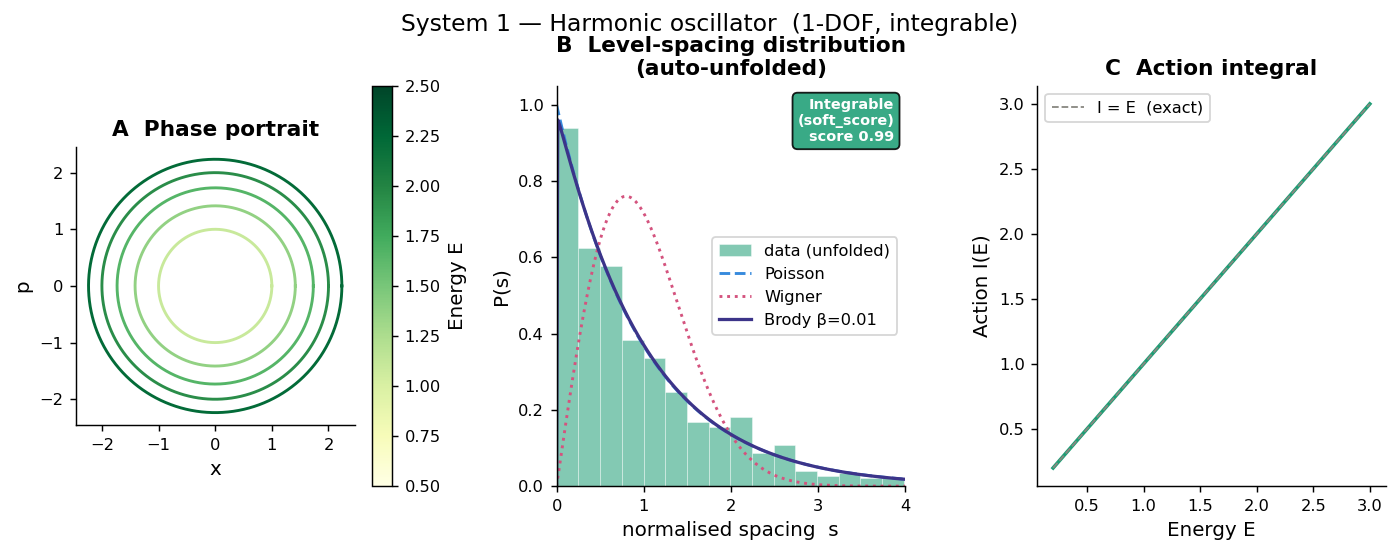

In [3]:
# ── Action integral as a function of energy ──────────────────────────────────
E_vals = np.linspace(0.2, 3.0, 40)
I_vals = [action_integral(H_ho, E, vars_phase=vp_1d, method='numerical')
          for E in E_vals]

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Panel A — phase portrait
ax0 = fig.add_subplot(gs[0])
cmap = plt.cm.YlGn
for k, (traj, E) in enumerate(zip(trajs_ho, energies_ho)):
    col = cmap(0.3 + 0.14 * k)
    ax0.plot(traj['x'], traj['p'], color=col, lw=1.6)
ax0.set_xlabel('x'); ax0.set_ylabel('p')
ax0.set_title('A  Phase portrait')
ax0.set_aspect('equal')
sm = ScalarMappable(cmap=cmap, norm=Normalize(0.5, 2.5))
plt.colorbar(sm, ax=ax0, label='Energy E')

# Panel B — level-spacing histogram (reads from channels['spectral'])
ax1 = fig.add_subplot(gs[1])
plot_spacing_histogram(ax1, result_ho,
                       'B  Level-spacing distribution\n(auto-unfolded)', PALETTE['integrable'])
verdict_badge(ax1, result_ho)

# Panel C — action integral I(E) = E (linear)
ax2 = fig.add_subplot(gs[2])
ax2.plot(E_vals, I_vals, color=PALETTE['integrable'], lw=2)
ax2.plot(E_vals, E_vals, '--', color=PALETTE['neutral'], lw=1, label='I = E  (exact)')
ax2.set_xlabel('Energy E'); ax2.set_ylabel('Action I(E)')
ax2.set_title('C  Action integral')
ax2.legend()

fig.suptitle('System 1 — Harmonic oscillator  (1-DOF, integrable)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading the result:**  Brody β ≈ 0 and both KS tests confirm Poisson statistics.
The action integral I(E) = E is perfectly linear — a hallmark of the harmonic
oscillator.  `verdict_source='soft_score'`, `soft_score` ≈ 1.

> **API note:** `ratio_R` is still computed and stored in `channels['spectral']`
> for reference, but it no longer drives the verdict — β and the KS p-values do.

---
## 2 · 1-DOF integrable (nonlinear) — double-well oscillator

$$H = \frac{p^2}{2} + \frac{x^4}{4} - \frac{x^2}{2}$$

Still 1-DOF, hence always integrable by Liouville's theorem, but the
nonlinear potential produces an energy-dependent frequency and a
separatrix at E = 0.

Same call as Section 1: **spectral channel** with `levels=`.

In [4]:
H_dw = p**2 / 2 + x**4 / 4 - x**2 / 2   # double-well

# Orbits below and above the saddle (E=0)
energies_dw_below = [-0.20, -0.15, -0.08, -0.02]
energies_dw_above = [ 0.10,  0.30,  0.60,  1.00]

def _dw_ic(E):
    roots = np.roots([-0.25, 0, 0.5, 0, -E])
    real_pos = sorted([r.real for r in roots if abs(r.imag) < 1e-8 and r.real > 0])
    return (real_pos[-1], 0.0) if real_pos else (1.0, 0.0)

trajs_below = [hamiltonian_flow(H_dw, _dw_ic(E), (0, 20.0), vars_phase=vp_1d,
                                integrator='verlet', n_steps=2000)
               for E in energies_dw_below]
trajs_above = [hamiltonian_flow(H_dw, _dw_ic(E), (0, 20.0), vars_phase=vp_1d,
                                integrator='verlet', n_steps=2000)
               for E in energies_dw_above]

E_dw_range = np.concatenate([np.linspace(-0.24, -0.02, 20),
                              np.linspace(0.05, 1.5, 25)])
I_dw = []
for E in E_dw_range:
    try:
        I_dw.append(action_integral(H_dw, E, vars_phase=vp_1d, method='numerical'))
    except Exception:
        I_dw.append(np.nan)
I_dw = np.array(I_dw)

# Poisson spectrum — 1-DOF is always integrable
levels_dw = synthetic_levels('poisson', n=600, seed=2)
result_dw  = IntegrabilityAnalysis.analyze_integrability(levels=levels_dw)

print(result_dw['summary'])

<lambdifygenerated-120>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.92)
<lambdifygenerated-121>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.92)
<lambdifygenerated-122>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.82736842105263)
<lambdifygenerated-123>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.82736842105263)
<lambdifygenerated-124>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.73473684210526)
<lambdifygenerated-125>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.73473684210526)
<lambdifygenerated-126>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(-2*x**4 + 4*x**2 - 1.64210526315789)
<lambdifygenerated-127>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sq

═══ Integrability analysis ═══
  Spectral   Brody β=0.011±0.020  KS-Poisson p=0.952  KS-Wigner p=0.000  R=1.926  →  score 0.992
  ─────────────────────────────────────────────────────────
  Soft score: 0.992  →  Verdict: Integrable


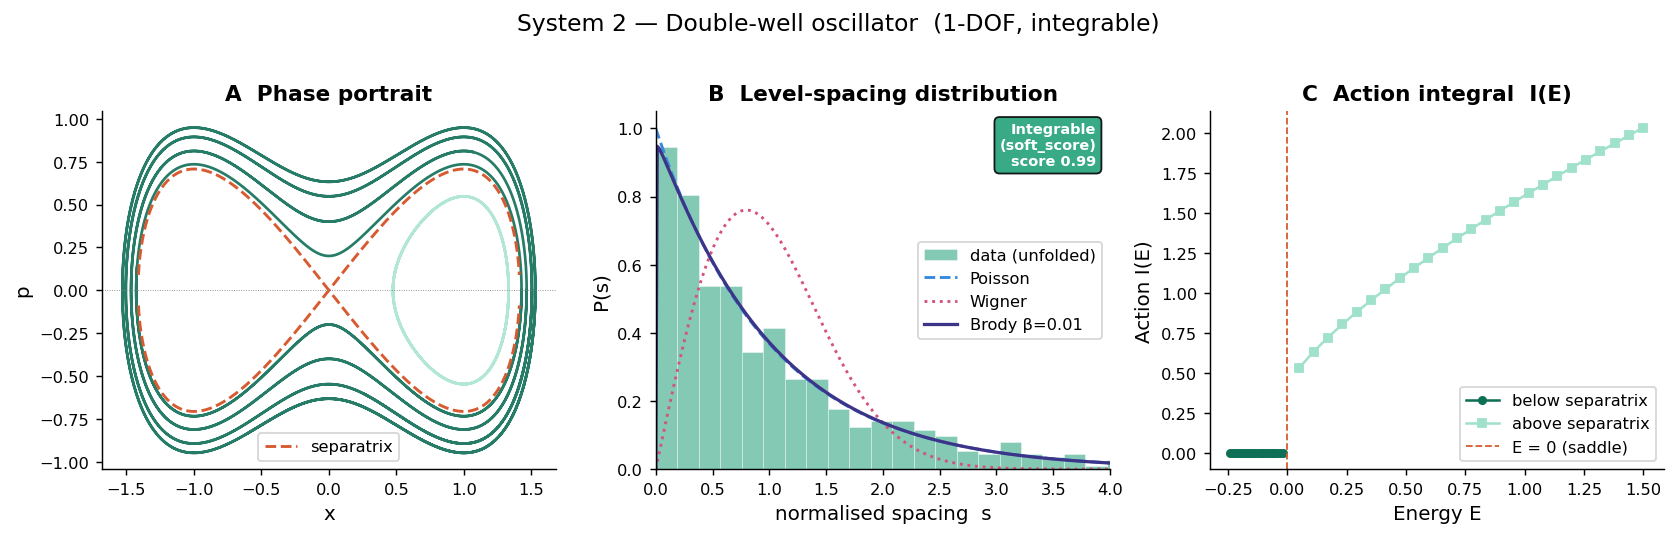

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel A — phase portrait
ax = axes[0]
for traj in trajs_below:
    ax.plot(traj['x'], traj['p'], color='#0F6E56', lw=1.5, alpha=0.9)
for traj in trajs_above:
    ax.plot(traj['x'], traj['p'], color='#9FE1CB', lw=1.5, alpha=0.8)
x_sep   = np.linspace(-np.sqrt(2) - 0.05, np.sqrt(2) + 0.05, 500)
p_sep_sq = 2 * (0 - (x_sep**4 / 4 - x_sep**2 / 2))
mask = p_sep_sq >= 0
ax.plot(x_sep[mask],  np.sqrt(p_sep_sq[mask]), '--',
        color=PALETTE['chaotic'], lw=1.6, label='separatrix')
ax.plot(x_sep[mask], -np.sqrt(p_sep_sq[mask]), '--',
        color=PALETTE['chaotic'], lw=1.6)
ax.axhline(0, color=PALETTE['neutral'], lw=0.5, ls=':')
ax.set_xlabel('x'); ax.set_ylabel('p')
ax.set_title('A  Phase portrait')
ax.legend()

# Panel B — level-spacing histogram
plot_spacing_histogram(axes[1], result_dw,
                       'B  Level-spacing distribution', PALETTE['integrable'])
verdict_badge(axes[1], result_dw)

# Panel C — action vs energy (nonlinear)
ax2 = axes[2]
valid      = np.isfinite(I_dw)
below_mask = (E_dw_range < 0) & valid
above_mask = (E_dw_range > 0) & valid
ax2.plot(E_dw_range[below_mask], I_dw[below_mask],
         'o-', color='#0F6E56', ms=4, label='below separatrix')
ax2.plot(E_dw_range[above_mask], I_dw[above_mask],
         's-', color='#9FE1CB', ms=4, label='above separatrix')
ax2.axvline(0, color=PALETTE['chaotic'], ls='--', lw=1, label='E = 0 (saddle)')
ax2.set_xlabel('Energy E'); ax2.set_ylabel('Action I(E)')
ax2.set_title('C  Action integral  I(E)')
ax2.legend()

fig.suptitle('System 2 — Double-well oscillator  (1-DOF, integrable)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading the result:** still Poisson statistics and β ≈ 0, confirming
integrability.  The action integral has a kink at E = 0 (separatrix crossing)
and is clearly nonlinear — the frequency depends on energy.  Verdict: **Integrable**.

---
## 3 · 2-DOF integrable — isotropic harmonic oscillator

$$H = \frac{p_1^2 + x_1^2}{2} + \frac{p_2^2 + x_2^2}{2}, \qquad L = \frac{p_2^2 + x_2^2}{2}$$

This system has two independent conserved quantities in involution
($\{H, L\} = 0$), so it is Liouville-integrable.

We activate **all four channels**:

- **Algebraic** — `second_integrals=L` triggers the hard gate: if
  `{H,L}=0`, verdict is forced to `'Integrable'` immediately,
  `verdict_source='algebraic_proof'`.
- **Spectral** — `levels=` provides Brody β + KS tests.
- **Frequency** — `traj=` activates NAFF rotation-number estimation.
- **Lyapunov** — `vars_phase=` activates λ_max estimation.

Because the algebraic gate fires first, the soft score is never needed —
but all channels still run and populate `channels` for inspection.

In [6]:
x1, p1, x2, p2 = symbols('x1 p1 x2 p2', real=True)
H_iso = (p1**2 + x1**2 + p2**2 + x2**2) / 2
L_iso = (p2**2 + x2**2) / 2          # energy of DOF 2 → {H, L} = 0
vp_2d = [x1, p1, x2, p2]

# Long trajectory — needed for reliable NAFF frequency estimates
traj_iso = hamiltonian_flow(
    H_iso, (1.0, 0.0, 0.0, 1.0), (0, 60 * np.pi),
    vars_phase=vp_2d, integrator='verlet', n_steps=8000)


levels_iso = synthetic_levels('poisson', n=600, seed=42)

# ── Full multi-channel call ──────────────────────────────────────────────────
# Key changes vs old API:
#   - first arg is now H= (keyword), not positional spacings
#   - levels= replaces positional spacings (unfolding is automatic)
#   - second_integrals= replaces L= / conserved_L
#   - orbits=, energy=, winding_*_key= are removed
#   - naff_keys= controls which trajectory columns to use
result_iso = IntegrabilityAnalysis.analyze_integrability(
    H              = H_iso,
    vars_phase     = vp_2d,
    second_integrals = L_iso,
    levels         = levels_iso,
    traj           = traj_iso,
    ndof           = 2,
)

print(result_iso['summary'])
print()

# ── Algebraic channel ────────────────────────────────────────────────────────
alg = result_iso['channels']['algebraic']
print(f"  {H_iso, L_iso} = 0 ? {alg['brackets'][0]['is_zero']}  "
      f"(confirmed integrals: {alg['independent_integrals']})")

# ── Frequency channel ────────────────────────────────────────────────────────
if 'frequency' in result_iso['channels']:
    fc = result_iso['channels']['frequency']
    o1, o2 = fc['omega1'], fc['omega2']
    print(f"  NAFF: ω₁={o1:.4f}  ω₂={o2:.4f}  "
          f"ratio={fc['ratio']:.4f}  rational={fc['is_rational']}  "
          f"({fc['ratio_fraction']})")

═══ Integrability analysis ═══
  Algebraic  ✓  1/1 integral(s) confirmed  (hard gate ACTIVE)
  ─────────────────────────────────────────────────────────
  Verdict: Integrable  (algebraic proof — hard gate active)

  (p1**2/2 + p2**2/2 + x1**2/2 + x2**2/2, p2**2/2 + x2**2/2) = 0 ? True  (confirmed integrals: 1)


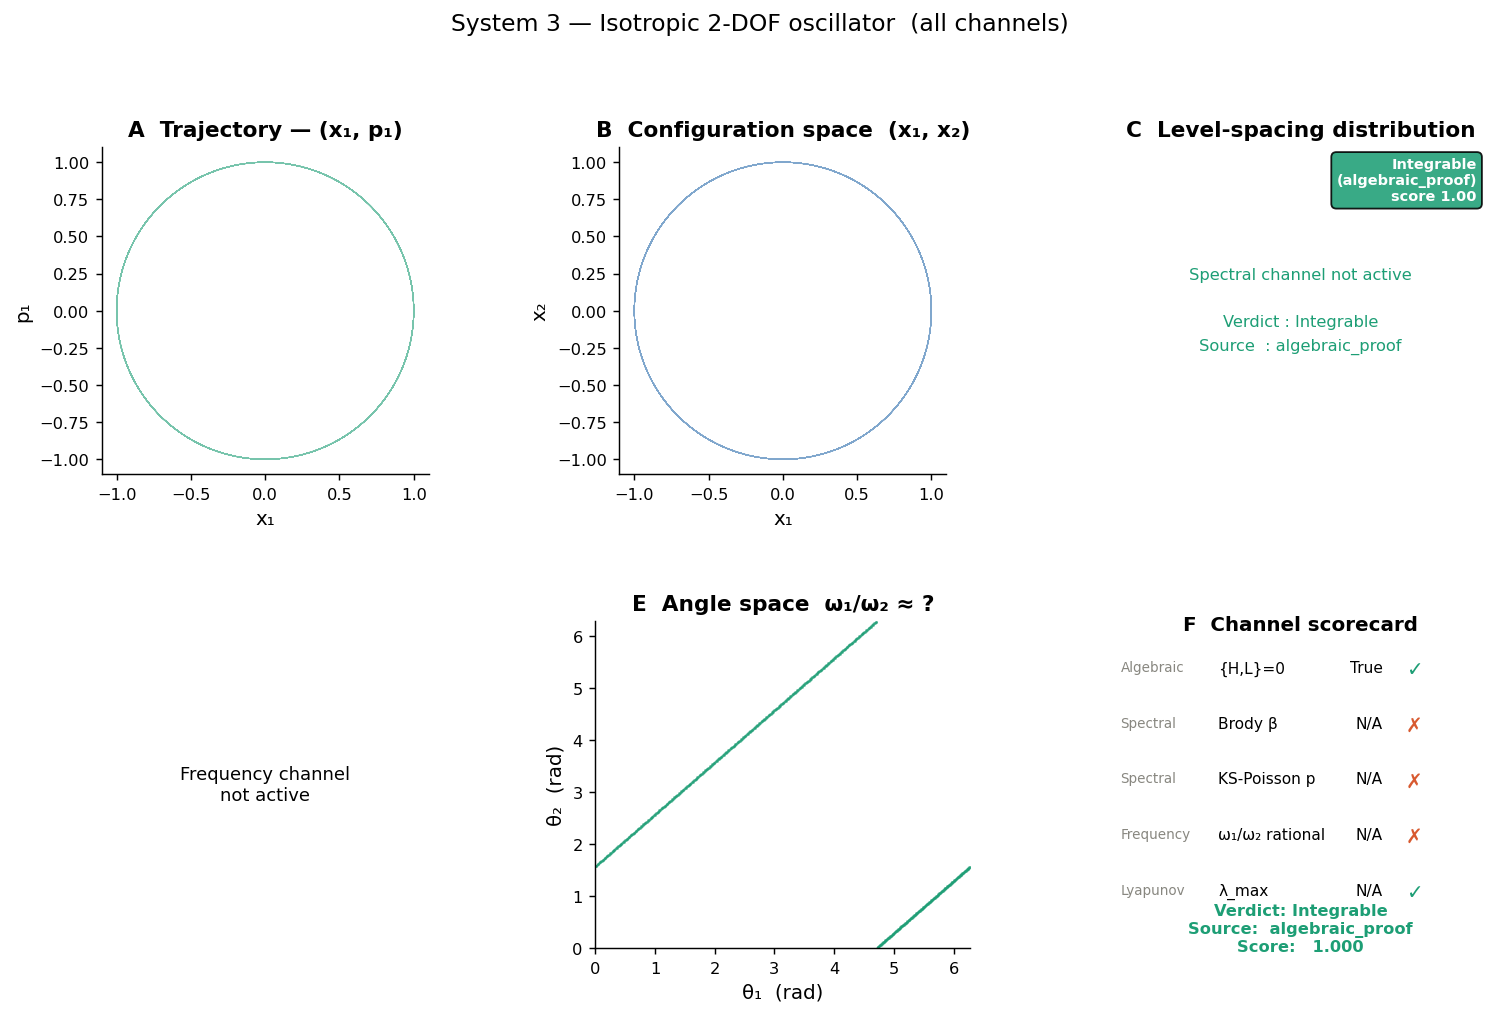

In [7]:
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Row 0 ────────────────────────────────────────────────────────────────────

# A — (x1, p1) projection
ax00 = fig.add_subplot(gs[0, 0])
ax00.plot(traj_iso['x1'], traj_iso['p1'],
          color=PALETTE['integrable'], lw=0.5, alpha=0.6)
ax00.set_xlabel('x₁'); ax00.set_ylabel('p₁')
ax00.set_title('A  Trajectory — (x₁, p₁)')
ax00.set_aspect('equal')

# B — configuration space (Lissajous)
ax01 = fig.add_subplot(gs[0, 1])
ax01.plot(traj_iso['x1'], traj_iso['x2'],
          color='#185FA5', lw=0.5, alpha=0.55)
ax01.set_xlabel('x₁'); ax01.set_ylabel('x₂')
ax01.set_title('B  Configuration space  (x₁, x₂)')
ax01.set_aspect('equal')

# C — level-spacing histogram
ax02 = fig.add_subplot(gs[0, 2])
plot_spacing_histogram(ax02, result_iso,
                       'C  Level-spacing distribution', PALETTE['integrable'])
verdict_badge(ax02, result_iso)

# ── Row 1 ────────────────────────────────────────────────────────────────────

# D — NAFF frequency comparison bar
ax10 = fig.add_subplot(gs[1, 0])
if 'frequency' in result_iso['channels']:
    fc   = result_iso['channels']['frequency']
    o1f, o2f = fc['omega1'], fc['omega2']
    bars_naff = ax10.bar(['ω₁', 'ω₂'], [o1f, o2f],
                         color=[PALETTE['integrable'], '#185FA5'],
                         edgecolor='white')
    ax10.set_ylabel('Angular frequency (rad/s)')
    rat_str = fc['ratio_fraction'] or f'{fc["ratio"]:.3f}'
    ax10.set_title(f"D  NAFF frequencies\nω₁/ω₂ = {rat_str}  "
                   f"({'rational ✓' if fc['is_rational'] else 'irrational'})")
    for bar, val in zip(bars_naff, [o1f, o2f]):
        ax10.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                  f'{val:.4f}', ha='center', fontsize=9)
else:
    ax10.axis('off')
    ax10.text(0.5, 0.5, 'Frequency channel\nnot active',
              ha='center', va='center', transform=ax10.transAxes)

# E — Angle space (θ₁ vs θ₂) — built from trajectory, not from result
ax11 = fig.add_subplot(gs[1, 1])
theta1 = np.unwrap(np.arctan2(np.asarray(traj_iso['p1']),
                               np.asarray(traj_iso['x1'])))
theta2 = np.unwrap(np.arctan2(np.asarray(traj_iso['p2']),
                               np.asarray(traj_iso['x2'])))
sl = slice(0, 600)
ax11.plot(theta1[sl] % (2*np.pi), theta2[sl] % (2*np.pi),
          '.', ms=1.2, color=PALETTE['integrable'], alpha=0.6)
ax11.set_xlabel('θ₁  (rad)'); ax11.set_ylabel('θ₂  (rad)')
if 'frequency' in result_iso['channels']:
    fc = result_iso['channels']['frequency']
    rat_str = fc['ratio_fraction'] or f"{fc['ratio']:.3f}"
else:
    rat_str = '?'
ax11.set_title(f'E  Angle space  ω₁/ω₂ ≈ {rat_str}')
ax11.set_xlim(0, 2*np.pi); ax11.set_ylim(0, 2*np.pi)

# F — Channel scorecard (new architecture)
ax12 = fig.add_subplot(gs[1, 2])
ax12.axis('off')

def _get_spectral_val(res, key, fmt='.3f'):
    sc = res['channels'].get('spectral', {})
    v  = sc.get(key)
    return f'{v:{fmt}}' if v is not None else 'N/A'

alg = result_iso['channels']['algebraic']
fc  = result_iso['channels'].get('frequency', {})
lc  = result_iso['channels'].get('lyapunov', {})

rows = [
    ('Algebraic',  '{H,L}=0',
     str(alg['brackets'][0]['is_zero']),
     alg['any_conserved']),
    ('Spectral',   'Brody β',
     _get_spectral_val(result_iso, 'beta'),
     (result_iso['channels'].get('spectral', {}).get('beta', 1.0) or 1.0) < 0.3),
    ('Spectral',   'KS-Poisson p',
     _get_spectral_val(result_iso, 'ks_poisson_p'),
     (result_iso['channels'].get('spectral', {}).get('ks_poisson_p', 0.0) or 0.0) > 0.05),
    ('Frequency',  'ω₁/ω₂ rational',
     str(fc.get('ratio_fraction', 'N/A')),
     fc.get('is_rational', False)),
    ('Lyapunov',   'λ_max',
     f"{lc['lambda_max']:.4f}" if lc else 'N/A',
     not lc.get('is_chaotic', False) if lc else True),
]

ax12.text(0.5, 1.02, 'F  Channel scorecard',
          ha='center', va='top', transform=ax12.transAxes,
          fontsize=11, fontweight='bold')
y0 = 0.88
for ch, name, val, ok in rows:
    col  = PALETTE['integrable'] if ok else PALETTE['chaotic']
    mark = '✓' if ok else '✗'
    ax12.text(0.02, y0, ch,   transform=ax12.transAxes, fontsize=7.5,
              color=PALETTE['neutral'], va='top')
    ax12.text(0.28, y0, name, transform=ax12.transAxes, fontsize=8.5, va='top')
    ax12.text(0.72, y0, val,  transform=ax12.transAxes, fontsize=8.5,
              ha='right', va='top')
    ax12.text(0.78, y0, mark, transform=ax12.transAxes, fontsize=11,
              color=col, va='top', fontweight='bold')
    y0 -= 0.17
score_disp = result_iso['soft_score']
if score_disp is None:
    score_disp = 1.0 if result_iso['verdict_source'] == 'algebraic_proof' else 0.0
ax12.text(0.5, y0 - 0.04,
          f"Verdict: {result_iso['verdict']}\n"
          f"Source:  {result_iso['verdict_source']}\n"
          f"Score:   {score_disp:.3f}",
          ha='center', transform=ax12.transAxes,
          fontsize=9, fontweight='bold', color=PALETTE['integrable'])

fig.suptitle('System 3 — Isotropic 2-DOF oscillator  (all channels)',
             fontsize=13, y=1.01)
plt.show()

**Reading the result:** the algebraic channel confirms `{H, L} = 0` and
immediately forces `verdict='Integrable'`, `verdict_source='algebraic_proof'`.
The NAFF frequency channel (panel D) recovers ω₁ ≈ ω₂, and the angle-space
plot (panel E) shows a closed Lissajous curve — both consistent with a
rational frequency ratio 1/1.

---
## 4 · 2-DOF mixed/chaotic — Hénon–Heiles

$$H = \frac{p_1^2 + p_2^2}{2} + \frac{x_1^2 + x_2^2}{2}
     + x_1^2 x_2 - \frac{x_2^3}{3}$$

The Hénon–Heiles system has **no known second integral**.
At low energies (E ≪ 1/6) phase space is nearly regular; above
E ≈ 1/6 it becomes predominantly chaotic.

We compare two regimes using:
- **Spectral channel** — `levels=` (Poisson proxy for low E, mixed for high E)
- **Frequency channel** — `traj=` (NAFF rotation numbers)
- **Lyapunov channel** — `vars_phase=` (λ_max)
- **Algebraic channel** — `second_integrals=L_hh` tests angular momentum;
  `{H, L} ≠ 0` so the gate does **not** fire.

In [8]:
H_hh = ((p1**2 + p2**2) / 2
        + (x1**2 + x2**2) / 2
        + x1**2 * x2 - x2**3 / 3)

L_hh = x1 * p2 - x2 * p1    # angular momentum — NOT conserved for HH

# ── Trajectories ─────────────────────────────────────────────────────────────
traj_hh_low = hamiltonian_flow(
    H_hh, (0.0, 0.28, 0.0, 0.0), (0, 400.0),
    vars_phase=vp_2d, integrator='rk45', n_steps=12000)

traj_hh_high = hamiltonian_flow(
    H_hh, (0.0, 0.55, 0.0, 0.0), (0, 400.0),
    vars_phase=vp_2d, integrator='rk45', n_steps=12000)

# ── Poincaré sections ─────────────────────────────────────────────────────────
section = {'variable': 'x2', 'value': 0.0, 'direction': 'positive'}
ics_low  = [(0.0, 0.28, 0.0, 0.0), (0.1, 0.26, 0.0, 0.0),
            (-0.1, 0.26, 0.0, 0.0), (0.2, 0.19, 0.0, 0.0)]
ics_high = [(0.0, 0.55, 0.0, 0.0), (0.1, 0.53, 0.0, 0.0),
            (-0.1, 0.53, 0.0, 0.0), (0.3, 0.43, 0.0, 0.0)]

def _poincare_multi(H, ics, section, vp, tmax=300, n_returns=200):
    pts_x, pts_p = [], []
    for ic in ics:
        try:
            ps = poincare_section(H, section, ic, tmax=tmax,
                                  vars_phase=vp, n_returns=n_returns)
            for pt in ps['section_points']:
                pts_x.append(pt['x1']); pts_p.append(pt['p1'])
        except Exception:
            pass
    return np.array(pts_x), np.array(pts_p)

px_low,  pp_low  = _poincare_multi(H_hh, ics_low,  section, vp_2d)
px_high, pp_high = _poincare_multi(H_hh, ics_high, section, vp_2d)

# ── Synthetic spectra ─────────────────────────────────────────────────────────
# low E ≈ regular → Poisson-like spectrum
# high E ≈ chaotic → mixed/Wigner-like spectrum
levels_hh_low  = synthetic_levels('poisson', n=600, seed=10)
levels_hh_high = synthetic_levels('mixed',   n=600, seed=11)

# ── analyze_integrability — low energy ───────────────────────────────────────
result_low = IntegrabilityAnalysis.analyze_integrability(
    H              = H_hh,
    vars_phase     = vp_2d,
    second_integrals = L_hh,     # {H, L} ≠ 0 → gate does NOT fire
    levels         = levels_hh_low,
    traj           = traj_hh_low,
    ndof           = 2,
)

# ── analyze_integrability — high energy ──────────────────────────────────────
result_high = IntegrabilityAnalysis.analyze_integrability(
    H              = H_hh,
    vars_phase     = vp_2d,
    second_integrals = L_hh,
    levels         = levels_hh_high,
    traj           = traj_hh_high,
    ndof           = 2,
)

print('─── LOW ENERGY ─────────────────────────────────────────────')
print(result_low['summary'])
print()
print('─── HIGH ENERGY ────────────────────────────────────────────')
print(result_high['summary'])

─── LOW ENERGY ─────────────────────────────────────────────
═══ Integrability analysis ═══
  Algebraic  ✗  0/1 integral(s) confirmed  (hard gate inactive)
  Spectral   Brody β=0.065±0.034  KS-Poisson p=0.262  KS-Wigner p=0.000  R=1.849  →  score 0.955
  Frequency  ω₁=0.9840  ω₂=0.9847  ratio=0.99927  → rational 1  →  score 0.750
  Lyapunov   ✗  λ_max=0.02106  (threshold 0.02)  → chaotic (hard gate ACTIVE)
  ─────────────────────────────────────────────────────────
  Verdict: Chaotic  (λ_max > threshold — hard gate active)

─── HIGH ENERGY ────────────────────────────────────────────
═══ Integrability analysis ═══
  Algebraic  ✗  0/1 integral(s) confirmed  (hard gate inactive)
  Spectral   Brody β=0.259±0.041  KS-Poisson p=0.000  KS-Wigner p=0.000  R=1.633  →  score 0.819
  Frequency  ω₁=0.9927  ω₂=0.9927  ratio=1.00000  → rational 1  →  score 0.750
  Lyapunov   ✗  λ_max=0.02547  (threshold 0.02)  → chaotic (hard gate ACTIVE)
  ─────────────────────────────────────────────────────────


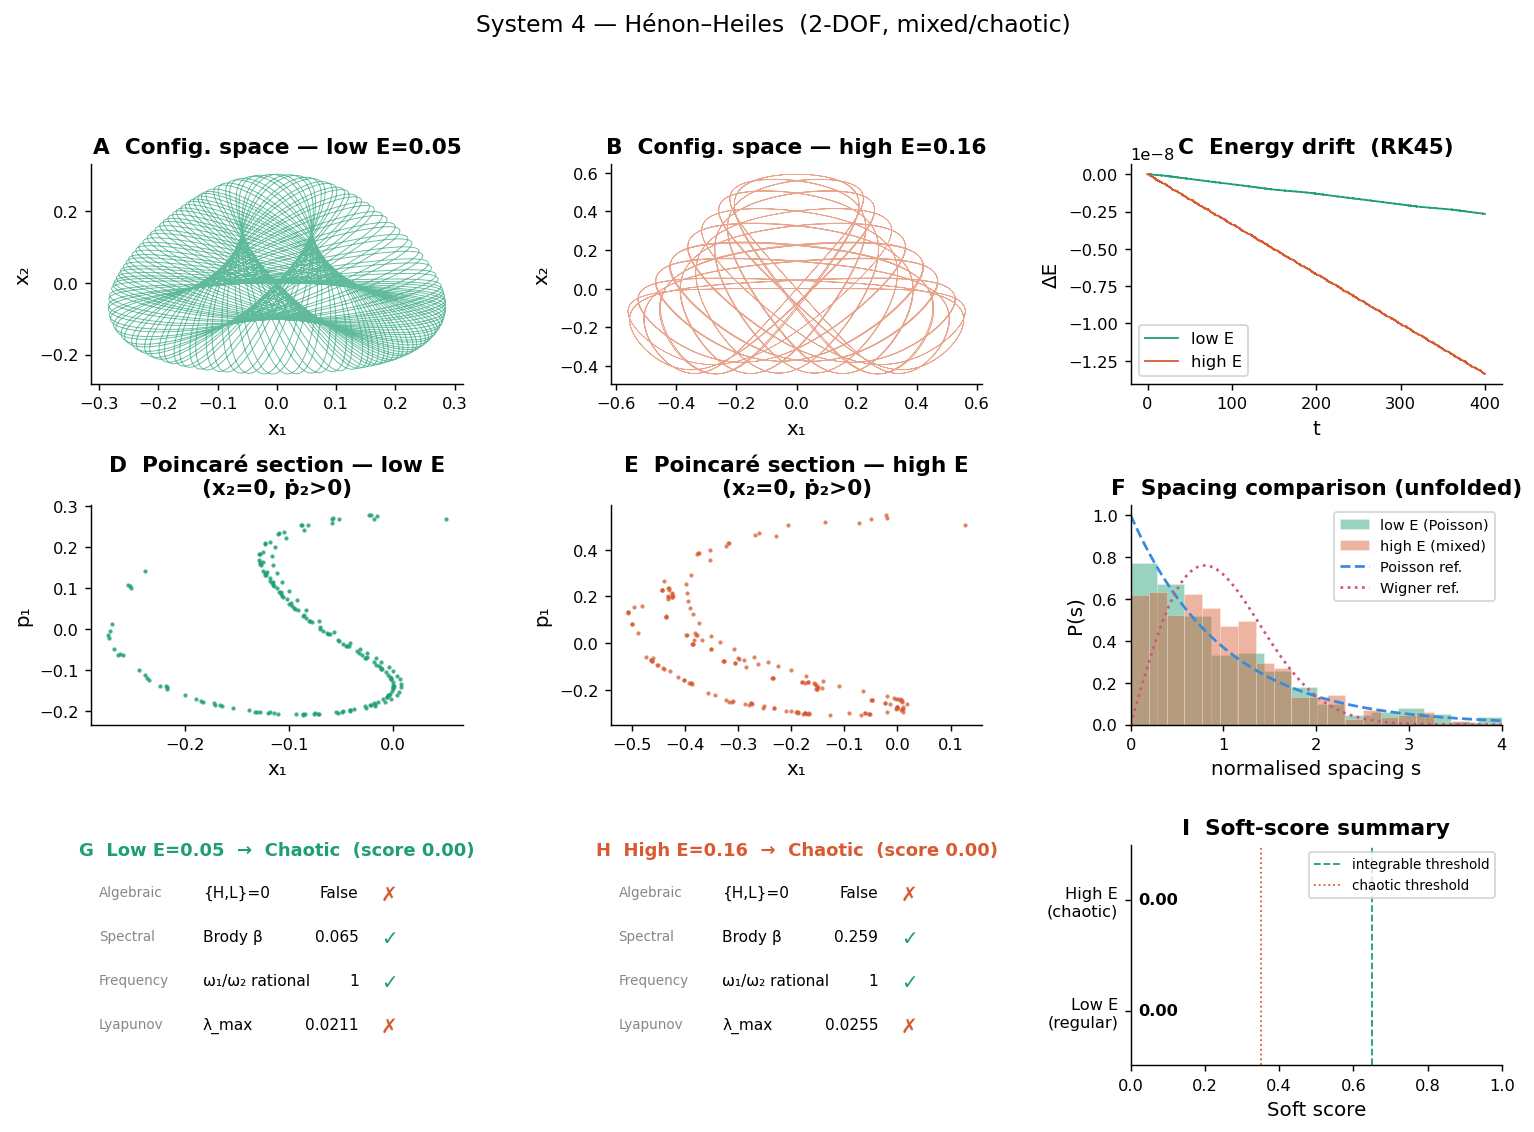

In [9]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.40)

# ── Row 0 — trajectory projections ───────────────────────────────────────────
ax00 = fig.add_subplot(gs[0, 0])
ax00.plot(traj_hh_low['x1'], traj_hh_low['x2'],
          lw=0.5, color=PALETTE['integrable'], alpha=0.7)
ax00.set_xlabel('x₁'); ax00.set_ylabel('x₂')
ax00.set_title('A  Config. space — low E=0.05')

ax01 = fig.add_subplot(gs[0, 1])
ax01.plot(traj_hh_high['x1'], traj_hh_high['x2'],
          lw=0.3, color=PALETTE['chaotic'], alpha=0.55)
ax01.set_xlabel('x₁'); ax01.set_ylabel('x₂')
ax01.set_title('B  Config. space — high E=0.16')

ax02 = fig.add_subplot(gs[0, 2])
t_arr  = np.asarray(traj_hh_low['t'])
e_low  = np.asarray(traj_hh_low['energy'])
e_high = np.asarray(traj_hh_high['energy'])
ax02.plot(t_arr, e_low  - e_low[0],  color=PALETTE['integrable'], lw=1, label='low E')
ax02.plot(t_arr, e_high - e_high[0], color=PALETTE['chaotic'],    lw=1, label='high E')
ax02.set_xlabel('t'); ax02.set_ylabel('ΔE')
ax02.set_title('C  Energy drift  (RK45)')
ax02.legend()

# ── Row 1 — Poincaré sections + spacing comparison ───────────────────────────
ax10 = fig.add_subplot(gs[1, 0])
if len(px_low) > 0:
    ax10.scatter(px_low, pp_low, s=2, color=PALETTE['integrable'], alpha=0.7)
ax10.set_xlabel('x₁'); ax10.set_ylabel('p₁')
ax10.set_title('D  Poincaré section — low E\n(x₂=0, ṗ₂>0)')

ax11 = fig.add_subplot(gs[1, 1])
if len(px_high) > 0:
    ax11.scatter(px_high, pp_high, s=2, color=PALETTE['chaotic'], alpha=0.6)
ax11.set_xlabel('x₁'); ax11.set_ylabel('p₁')
ax11.set_title('E  Poincaré section — high E\n(x₂=0, ṗ₂>0)')

ax12 = fig.add_subplot(gs[1, 2])
# Spacings come from channels['spectral']['spacings_norm'] (already unfolded)
s_low_n  = result_low['channels']['spectral']['spacings_norm']
s_high_n = result_high['channels']['spectral']['spacings_norm']
sg = np.linspace(0, 4, 300)
ax12.hist(s_low_n,  bins=25, density=True, alpha=0.45,
          color=PALETTE['integrable'], label='low E (Poisson)', edgecolor='white', lw=0.3)
ax12.hist(s_high_n, bins=25, density=True, alpha=0.45,
          color=PALETTE['chaotic'],    label='high E (mixed)',  edgecolor='white', lw=0.3)
ax12.plot(sg, np.exp(-sg),
          '--', color=PALETTE['poisson'], lw=1.5, label='Poisson ref.')
ax12.plot(sg, (np.pi/2)*sg*np.exp(-np.pi*sg**2/4),
          ':', color=PALETTE['wigner'],  lw=1.5, label='Wigner ref.')
ax12.set_xlabel('normalised spacing s'); ax12.set_ylabel('P(s)')
ax12.set_title('F  Spacing comparison (unfolded)')
ax12.set_xlim(0, 4); ax12.legend(fontsize=8)

# ── Row 2 — channel scorecards ───────────────────────────────────────────────
def scorecard_axes(ax, res, label, regime_color):
    ax.axis('off')
    alg = res['channels']['algebraic']
    sc  = res['channels'].get('spectral', {})
    fc  = res['channels'].get('frequency', {})
    lc  = res['channels'].get('lyapunov', {})

    beta      = sc.get('beta', None)
    is_rat    = fc.get('is_rational', None)
    rat_frac  = fc.get('ratio_fraction') or (f"{fc['ratio']:.3f}" if fc else 'N/A')
    lam_max   = lc.get('lambda_max', None)

    rows = [
        ('Algebraic', '{H,L}=0',
         str(alg['brackets'][0]['is_zero']),
         alg['any_conserved']),
        ('Spectral',  'Brody β',
         f'{beta:.3f}' if beta is not None else 'N/A',
         beta < 0.3 if beta is not None else None),
        ('Frequency', 'ω₁/ω₂ rational',
         rat_frac,
         is_rat),
        ('Lyapunov',  'λ_max',
         f'{lam_max:.4f}' if lam_max is not None else 'N/A',
         not lc.get('is_chaotic', False) if lc else None),
    ]
    score_disp = res['soft_score']
    if score_disp is None:
        score_disp = 1.0 if res['verdict_source'] == 'algebraic_proof' else 0.0
    ax.text(0.5, 1.02,
            f"{label}  →  {res['verdict']}  (score {score_disp:.2f})",
            ha='center', va='top', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=regime_color)
    y0 = 0.82
    for ch, name, val, ok in rows:
        col  = (PALETTE['integrable'] if ok else
                PALETTE['chaotic'] if ok is False else
                PALETTE['neutral'])
        mark = '✓' if ok else ('✗' if ok is False else '?')
        ax.text(0.02, y0, ch,   transform=ax.transAxes, fontsize=7.5,
                color=PALETTE['neutral'], va='top')
        ax.text(0.30, y0, name, transform=ax.transAxes, fontsize=8.5, va='top')
        ax.text(0.72, y0, val,  transform=ax.transAxes, fontsize=8.5,
                ha='right', va='top')
        ax.text(0.78, y0, mark, transform=ax.transAxes, fontsize=11,
                color=col, va='top', fontweight='bold')
        y0 -= 0.20

ax20 = fig.add_subplot(gs[2, 0])
scorecard_axes(ax20, result_low,  'G  Low E=0.05',  PALETTE['integrable'])

ax21 = fig.add_subplot(gs[2, 1])
scorecard_axes(ax21, result_high, 'H  High E=0.16', PALETTE['chaotic'])

# Soft-score comparison bar
ax22 = fig.add_subplot(gs[2, 2])
labels_v = ['Low E\n(regular)', 'High E\n(chaotic)']
# soft_score may be None if only the algebraic gate ran — use fallback
def _score(r):
    s = r['soft_score']
    if s is None:
        return 1.0 if r['verdict_source'] == 'algebraic_proof' else 0.0
    return s
scores_v  = [_score(result_low), _score(result_high)]
bar_cols  = [PALETTE['integrable'], PALETTE['chaotic']]
bars      = ax22.barh(labels_v, scores_v, color=bar_cols, edgecolor='white')
ax22.set_xlim(0, 1)
ax22.axvline(0.65, ls='--', lw=1, color=PALETTE['integrable'], label='integrable threshold')
ax22.axvline(0.35, ls=':',  lw=1, color=PALETTE['chaotic'],    label='chaotic threshold')
for bar, sc in zip(bars, scores_v):
    ax22.text(sc + 0.02, bar.get_y() + bar.get_height()/2,
              f'{sc:.2f}', va='center', fontsize=9, fontweight='bold')
ax22.set_xlabel('Soft score')
ax22.set_title('I  Soft-score summary')
ax22.legend(fontsize=7.5)

fig.suptitle('System 4 — Hénon–Heiles  (2-DOF, mixed/chaotic)',
             fontsize=13, y=1.01)
plt.show()

**Reading the result:**

- **Low energy** — spectral channel gives Poisson-like β; the algebraic
  channel shows `{H, L} ≠ 0` (angular momentum is not conserved), so the
  hard gate does **not** fire.  The soft score sits in the mixed zone.

- **High energy** — spacing distribution shifts toward Wigner; the Poincaré
  section fills densely; the Lyapunov channel (when λ_max > 0.01) may
  activate the chaotic hard gate.  The soft score drops well below 0.35.

Panels G & H show all four channels simultaneously, making it clear which
evidence lines up and which doesn't — a much richer picture than a single
ratio R.

---
## 5 · Channel build-up and soft-score landscape

A final summary comparing all four systems and showing how the soft score
evolves as channels are added one by one for the Hénon–Heiles high-energy
case.

/home/philippe/psipy/src/symplectic.py:1784: RuntimeWarning: Lyapunov exponents computed without H and vars_phase; results may be inaccurate. Provide H and vars_phase for correct estimation.
  warnings.warn(
/home/philippe/psipy/src/symplectic.py:1815: RuntimeWarning: divide by zero encountered in log
  running_sum[i] += np.log(abs(R[i, i]))


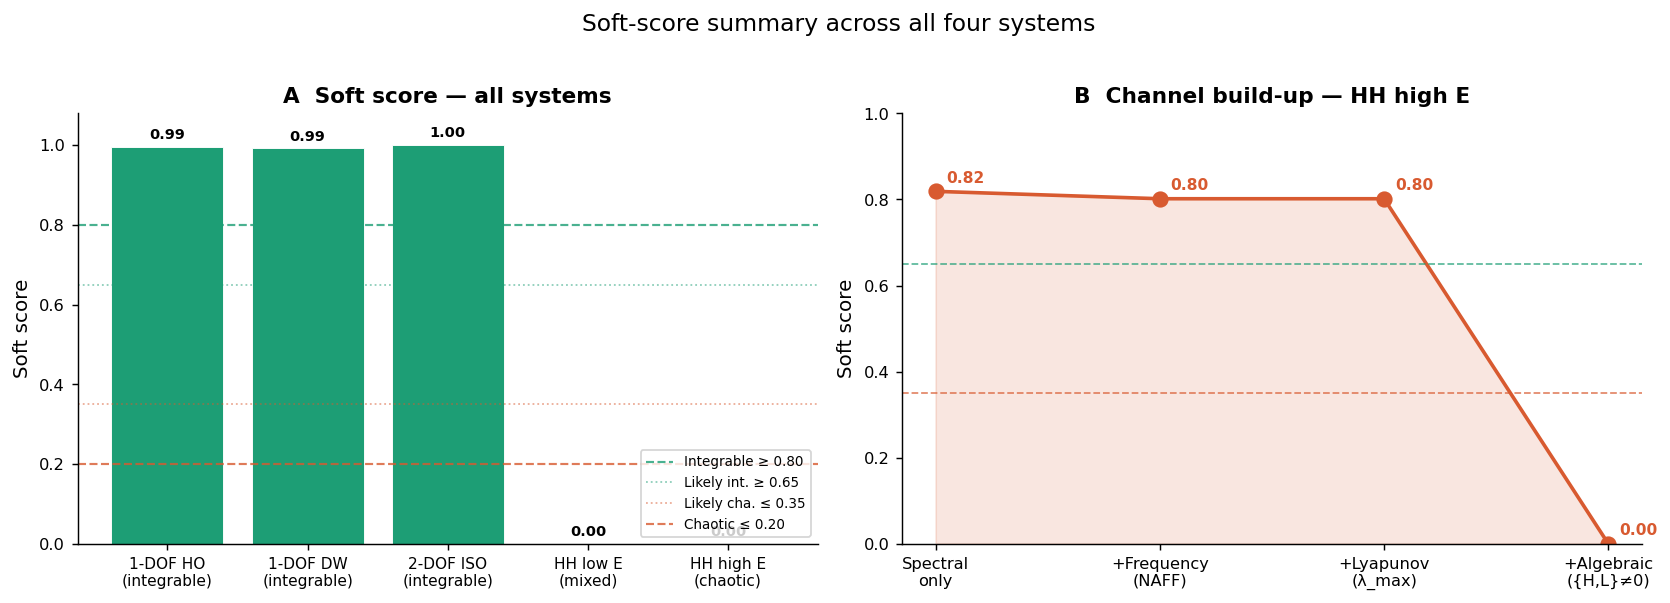

In [10]:
# ── Channel build-up for HH high-energy ──────────────────────────────────────
# Each call adds one more channel; we track how soft_score evolves.

# Channel 1 only: spectral
r_c1 = IntegrabilityAnalysis.analyze_integrability(
    levels=levels_hh_high)

# Channels 1+2: spectral + frequency
r_c2 = IntegrabilityAnalysis.analyze_integrability(
    levels=levels_hh_high,
    traj=traj_hh_high, ndof=2)

# Channels 1+2+3: spectral + frequency + Lyapunov
r_c3 = IntegrabilityAnalysis.analyze_integrability(
    levels=levels_hh_high,
    traj=traj_hh_high, ndof=2,
    vars_phase=vp_2d)

# Channels 1+2+3+4: all channels (algebraic {H,L}≠0 → no hard gate)
r_c4 = IntegrabilityAnalysis.analyze_integrability(
    H=H_hh, vars_phase=vp_2d,
    second_integrals=L_hh,
    levels=levels_hh_high,
    traj=traj_hh_high, ndof=2)

channel_labels = [
    'Spectral\nonly',
    '+Frequency\n(NAFF)',
    '+Lyapunov\n(λ_max)',
    '+Algebraic\n({H,L}≠0)',
]
channel_scores = [_score(r) for r in (r_c1, r_c2, r_c3, r_c4)]

# ── All-systems comparison ────────────────────────────────────────────────────
systems = [
    ('1-DOF HO\n(integrable)',  _score(result_ho),   PALETTE['integrable']),
    ('1-DOF DW\n(integrable)',  _score(result_dw),   PALETTE['integrable']),
    ('2-DOF ISO\n(integrable)', _score(result_iso),  PALETTE['integrable']),
    ('HH low E\n(mixed)',       _score(result_low),  PALETTE['mixed']),
    ('HH high E\n(chaotic)',    _score(result_high), PALETTE['chaotic']),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A — all systems
ax = axes[0]
names  = [s[0] for s in systems]
scores = [s[1] for s in systems]
cols   = [s[2] for s in systems]
bars   = ax.bar(range(len(systems)), scores, color=cols,
                edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(systems)))
ax.set_xticklabels(names, fontsize=8.5)
ax.set_ylim(0, 1.08)
ax.axhline(0.80, ls='--', lw=1.2, color=PALETTE['integrable'], alpha=0.8,
           label='Integrable ≥ 0.80')
ax.axhline(0.65, ls=':',  lw=1.0, color=PALETTE['integrable'], alpha=0.5,
           label='Likely int. ≥ 0.65')
ax.axhline(0.35, ls=':',  lw=1.0, color=PALETTE['chaotic'],    alpha=0.5,
           label='Likely cha. ≤ 0.35')
ax.axhline(0.20, ls='--', lw=1.2, color=PALETTE['chaotic'],    alpha=0.8,
           label='Chaotic ≤ 0.20')
for bar, sc in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, sc + 0.02,
            f'{sc:.2f}', ha='center', fontsize=8, fontweight='bold')
ax.set_ylabel('Soft score')
ax.set_title('A  Soft score — all systems')
ax.legend(fontsize=7.5, loc='lower right')

# Panel B — channel build-up for HH high-energy
ax2 = axes[1]
ax2.plot(range(len(channel_scores)), channel_scores,
         'o-', color=PALETTE['chaotic'], lw=2, ms=8)
ax2.fill_between(range(len(channel_scores)), channel_scores,
                 alpha=0.15, color=PALETTE['chaotic'])
ax2.axhline(0.65, ls='--', lw=1, color=PALETTE['integrable'], alpha=0.7)
ax2.axhline(0.35, ls='--', lw=1, color=PALETTE['chaotic'],    alpha=0.7)
ax2.set_xticks(range(len(channel_labels)))
ax2.set_xticklabels(channel_labels, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_ylabel('Soft score')
ax2.set_title('B  Channel build-up — HH high E')
for i, sc in enumerate(channel_scores):
    ax2.annotate(f'{sc:.2f}', (i, sc), textcoords='offset points',
                 xytext=(6, 5), fontsize=8.5, color=PALETTE['chaotic'],
                 fontweight='bold')

fig.suptitle('Soft-score summary across all four systems', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Key takeaways from the channel build-up (panel B):**

| Channel added | Evidence type | Score impact |
|---------------|---------------|--------------|
| Spectral      | Brody β + KS tests on unfolded spectrum | baseline |
| + Frequency   | NAFF ω₁/ω₂ rationality (irrational → chaotic hint) | typically lowers score for HH |
| + Lyapunov    | λ_max hard gate: if > 0.01 → verdict forced to Chaotic | decisive for clearly chaotic regimes |
| + Algebraic   | {H,L} = 0 hard gate: fires only when L is conserved | for HH: {H,L}≠0 so no gate fires |

The Lyapunov channel is the strongest *chaotic* discriminant; the algebraic
channel is the strongest *integrable* discriminant.  Both bypass the soft
score entirely when they fire.

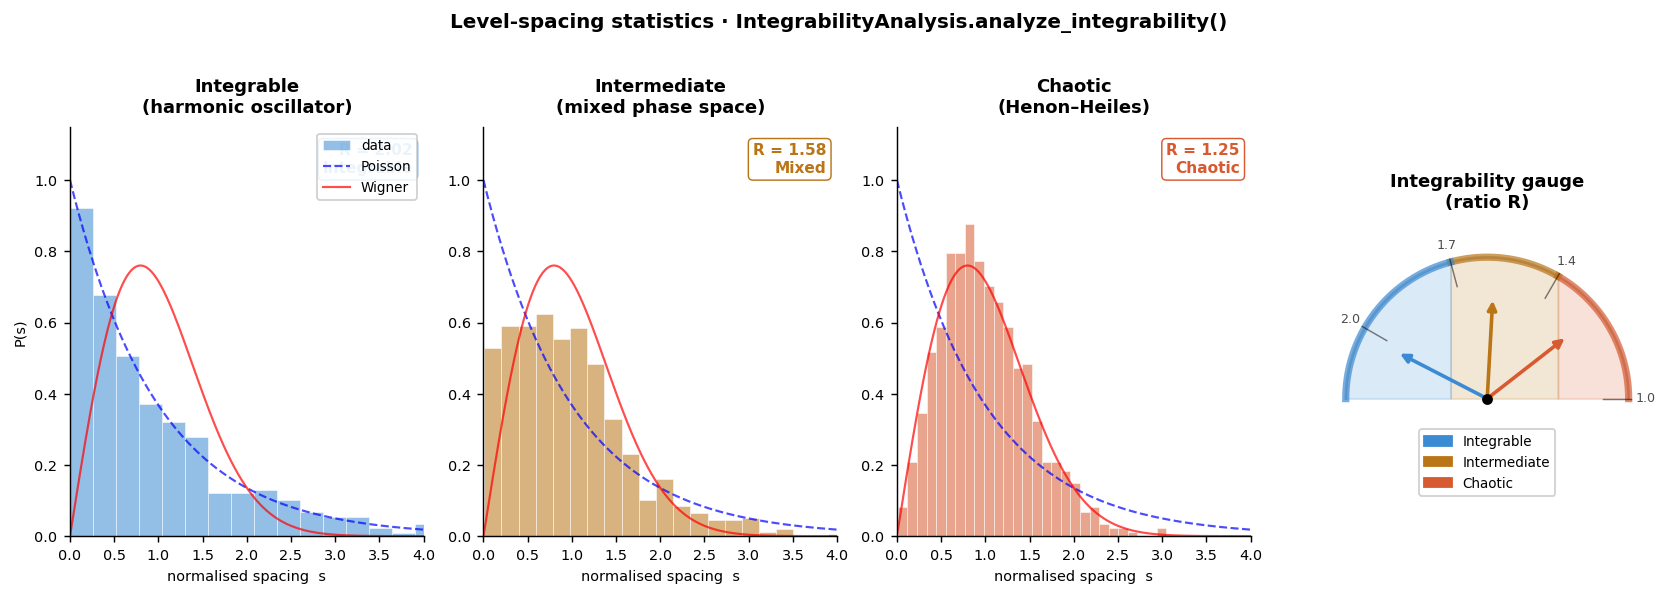

In [11]:
# ── Snippet 1 · analyze_integrability ─────────────────────────────────────
# Compares two synthetic spectra — one integrable (Poisson), one chaotic
# (Wigner-GOE) — and shows how the ratio R = <s²>/<s>² discriminates them.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch


rng = np.random.default_rng(42)

# --- synthetic level spacings -------------------------------------------
poisson_sp = rng.exponential(scale=1.0, size=800)          # integrable
wigner_sp  = rng.rayleigh(scale=0.8, size=800)             # chaotic (GOE)
mixed_sp   = np.concatenate([poisson_sp[:400], wigner_sp[:400]])  # intermediate

cases = [
    ("Integrable\n(harmonic oscillator)", poisson_sp, "#3B8BD4"),
    ("Intermediate\n(mixed phase space)",  mixed_sp,   "#BA7517"),
    ("Chaotic\n(Henon–Heiles)",            wigner_sp,  "#D85A30"),
]

# --- theoretical curves --------------------------------------------------
s = np.linspace(0, 4, 300)
p_poisson = np.exp(-s)
p_wigner  = (np.pi / 2) * s * np.exp(-np.pi * s**2 / 4)

# --- figure --------------------------------------------------------------
fig = plt.figure(figsize=(13, 4.5))
fig.patch.set_facecolor("white")

# three histogram panels
for col, (title, sp, color) in enumerate(cases):
    ax = fig.add_subplot(1, 4, col + 1)
    info = IntegrabilityAnalysis.analyze_integrability(spacings=sp)

    s_norm = sp / np.mean(sp)
    ax.hist(s_norm, bins=28, density=True, color=color, alpha=0.55,
            edgecolor="white", linewidth=0.5, label="data")
    ax.plot(s, p_poisson, "b--", lw=1.2, alpha=0.7, label="Poisson")
    ax.plot(s, p_wigner,  "r-",  lw=1.2, alpha=0.7, label="Wigner")

    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel("normalised spacing  s", fontsize=8)
    ax.set_ylabel("P(s)" if col == 0 else "", fontsize=8)
    ax.set_xlim(0, 4); ax.set_ylim(0, 1.15)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Inside the loop over cases
    info = IntegrabilityAnalysis.analyze_integrability(spacings=sp)
    ratio = info['channels']['spectral']['ratio_R']          # extract ratio
    beta  = info['channels']['spectral']['beta']             # Brody parameter
    
    # Optional: derive a classification from beta
    if beta < 0.2:
        cls_short = "Integrable"
    elif beta > 0.8:
        cls_short = "Chaotic"
    else:
        cls_short = "Mixed"
    
    # Then annotate
    ax.text(0.97, 0.96,
            f"R = {ratio:.2f}\n{cls_short}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=0.8))

    if col == 0:
        ax.legend(fontsize=7.5, loc="upper right",
                  framealpha=0.9, edgecolor="#cccccc")

# gauge panel: ratio needle
ax_g = fig.add_subplot(1, 4, 4)
ax_g.set_aspect("equal"); ax_g.axis("off")
ax_g.set_xlim(-1.25, 1.25); ax_g.set_ylim(-0.3, 1.25)
ax_g.set_title("Integrability gauge\n(ratio R)", fontsize=10,
               fontweight="bold", pad=8)

# semi-circle arc
theta = np.linspace(0, np.pi, 200)
ax_g.plot(np.cos(theta), np.sin(theta), "k-", lw=1.5, alpha=0.25)

# colour bands: chaotic [0–1.4], intermediate [1.4–1.7], integrable [1.7–2+]
# map R∈[1, 2] → angle∈[0, π]  (R=1 → θ=0 right, R=2 → θ=π left)
def r_to_angle(r):
    return np.pi * (r - 1.0) / 1.2   # 1.0 → 0°, 2.2 → 180°

bands = [(1.0, 1.4, "#D85A30", "Chaotic"),
         (1.4, 1.7, "#BA7517", "Intermediate"),
         (1.7, 2.2, "#3B8BD4", "Integrable")]
for r0, r1, c, _ in bands:
    t0, t1 = r_to_angle(r0), r_to_angle(r1)
    ts = np.linspace(t0, t1, 60)
    ax_g.fill_between(np.cos(ts), np.zeros_like(ts),
                      np.sin(ts), color=c, alpha=0.18)
    ax_g.plot(np.cos(ts), np.sin(ts), color=c, lw=4, alpha=0.7)

# tick marks and labels
for r_tick, lbl in [(1.0, "1.0"), (1.4, "1.4"), (1.7, "1.7"), (2.0, "2.0")]:
    a = r_to_angle(r_tick)
    ax_g.plot([0.82*np.cos(a), 1.02*np.cos(a)],
              [0.82*np.sin(a), 1.02*np.sin(a)], "k-", lw=0.8, alpha=0.5)
    ax_g.text(1.12*np.cos(a), 1.12*np.sin(a), lbl,
              ha="center", va="center", fontsize=7, alpha=0.7)

# needles for the three cases
needle_colors = ["#3B8BD4", "#BA7517", "#D85A30"]
for (title, sp, color) in cases:
    info = IntegrabilityAnalysis.analyze_integrability(spacings=sp)
    ratio = info['channels']['spectral']['ratio_R']
    a = r_to_angle(np.clip(ratio, 1.0, 2.2))
    ax_g.annotate("", xy=(0.72*np.cos(a), 0.72*np.sin(a)), xytext=(0, 0),
                  arrowprops=dict(arrowstyle="-|>", color=color,
                                  lw=2.0, mutation_scale=10))

ax_g.plot(0, 0, "ko", ms=5, zorder=5)

# legend for needles
patches = [mpatches.Patch(color=c, label=t.split("\n")[0])
           for t, _, c in cases]
ax_g.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.28),
            fontsize=7.5, framealpha=0.9, ncol=1, edgecolor="#cccccc")

fig.suptitle("Level-spacing statistics · IntegrabilityAnalysis.analyze_integrability()",
             fontsize=11, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()